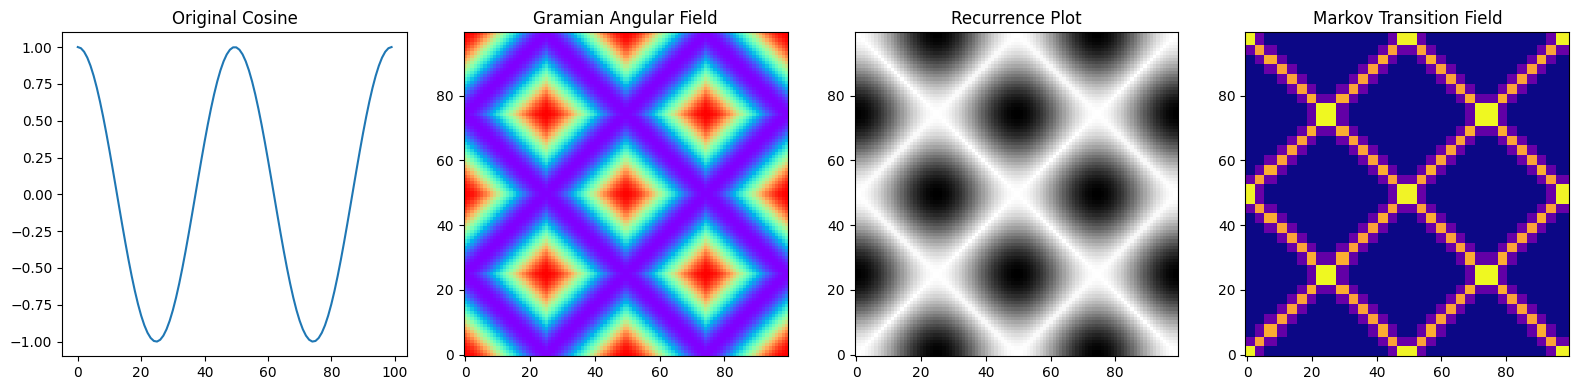

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pyts.image import GramianAngularField, RecurrencePlot, MarkovTransitionField

# 1. Create a 1D cosine signal
n_points = 100
time = np.linspace(0, 4 * np.pi, n_points)
signal = np.cos(time).reshape(1, -1)  # shape (1, n_timestamps)

# 2. GAF
gaf = GramianAngularField(method='summation')
gaf_img = gaf.fit_transform(signal)

# 3. RP
rp = RecurrencePlot()
rp_img = rp.fit_transform(signal)

# 4. MTF
mtf = MarkovTransitionField()
mtf_img = mtf.fit_transform(signal)

# 5. Plot all
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

axs[0].plot(signal[0])
axs[0].set_title("Original Cosine")

axs[1].imshow(gaf_img[0], cmap='rainbow', origin='lower')
axs[1].set_title("Gramian Angular Field")

axs[2].imshow(rp_img[0], cmap='binary', origin='lower')
axs[2].set_title("Recurrence Plot")

axs[3].imshow(mtf_img[0], cmap='plasma', origin='lower')
axs[3].set_title("Markov Transition Field")

plt.tight_layout()
plt.show()


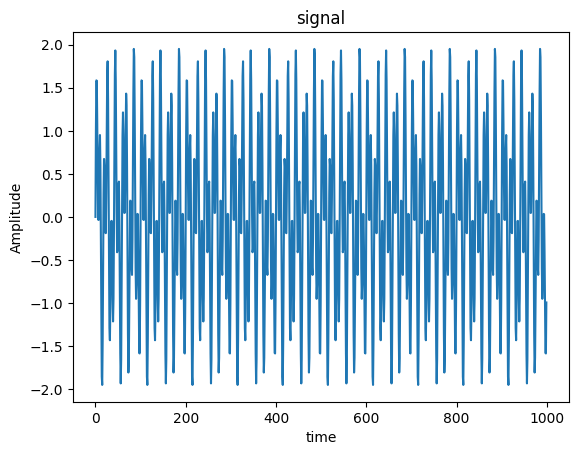

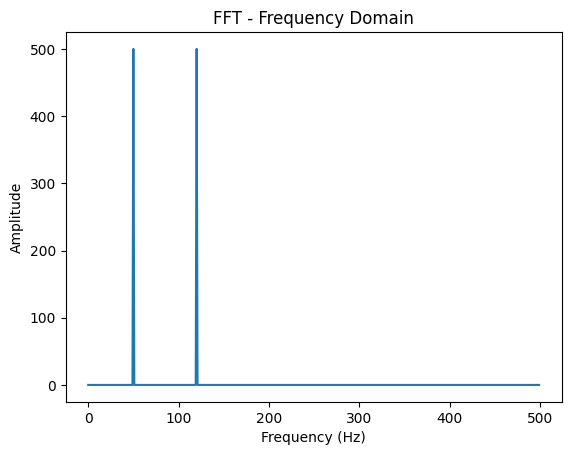

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Create a simple signal (1D, a combination of 2 frequencies)
sampling_rate = 1000  # samples per second
t = np.arange(0, 1, 1/sampling_rate)
signal = np.sin(2 * np.pi * 50 * t) + np.sin(2 * np.pi * 120 * t)

# Perform FFT
fft_result = np.fft.fft(signal)
fft_freq = np.fft.fftfreq(len(t), 1/sampling_rate)

# Plot the magnitude of the FFT (frequency domain representation)
plt.plot(signal)
plt.title("signal")
plt.xlabel("time")
plt.ylabel("Amplitude")
plt.show()

plt.plot(fft_freq[:len(fft_freq)//2], np.abs(fft_result)[:len(fft_result)//2])
plt.title("FFT - Frequency Domain")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import wfdb
import ast

def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

path = '../dataset/ptb_xl/'
sampling_rate=100

# load and convert annotation data
Y = pd.read_csv(path+'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

# Load raw signal data
X = load_raw_data(Y, sampling_rate, path)
# Load scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

# Apply diagnostic superclass
Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)

# Split data into train and test
test_fold = 10
# Train
X_train = X[np.where(Y.strat_fold != test_fold)]
y_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass
# Test
X_test = X[np.where(Y.strat_fold == test_fold)]
y_test = Y[Y.strat_fold == test_fold].diagnostic_superclass


In [ ]:
Y


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr,diagnostic_superclass
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr,[NORM]
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr,[NORM]
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr,[NORM]
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr,[NORM]
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr,[NORM]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21833,17180.0,67.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-05-31 09:14:35,ventrikulÄre extrasystole(n) sinustachykardie ...,...,NaN,", alles,",NaN,NaN,1ES,NaN,7,records100/21000/21833_lr,records500/21000/21833_hr,[STTC]
21834,20703.0,300.0,0,NaN,NaN,1.0,2.0,AT-60 3,2001-06-05 11:33:39,sinusrhythmus lagetyp normal qrs(t) abnorm ...,...,NaN,NaN,NaN,NaN,NaN,NaN,4,records100/21000/21834_lr,records500/21000/21834_hr,[NORM]
21835,19311.0,59.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-06-08 10:30:27,sinusrhythmus lagetyp normal t abnorm in anter...,...,NaN,", I-AVR,",NaN,NaN,NaN,NaN,2,records100/21000/21835_lr,records500/21000/21835_hr,[STTC]


In [ ]:
def plot_ecg_12_leads(data_plot, data_label=['NORM']):
    plt.figure(figsize=(24,12))
    print(f"Class {data_label}")
    for i in range(12):
        plt.subplot(4,3,i+1)
        plt.plot(data_plot[:, i])
        plt.title(f"Lead {i+1}")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.grid(True)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.show()

(19601, 1000, 12)
(19601,)
(12,)
Class ['NORM']


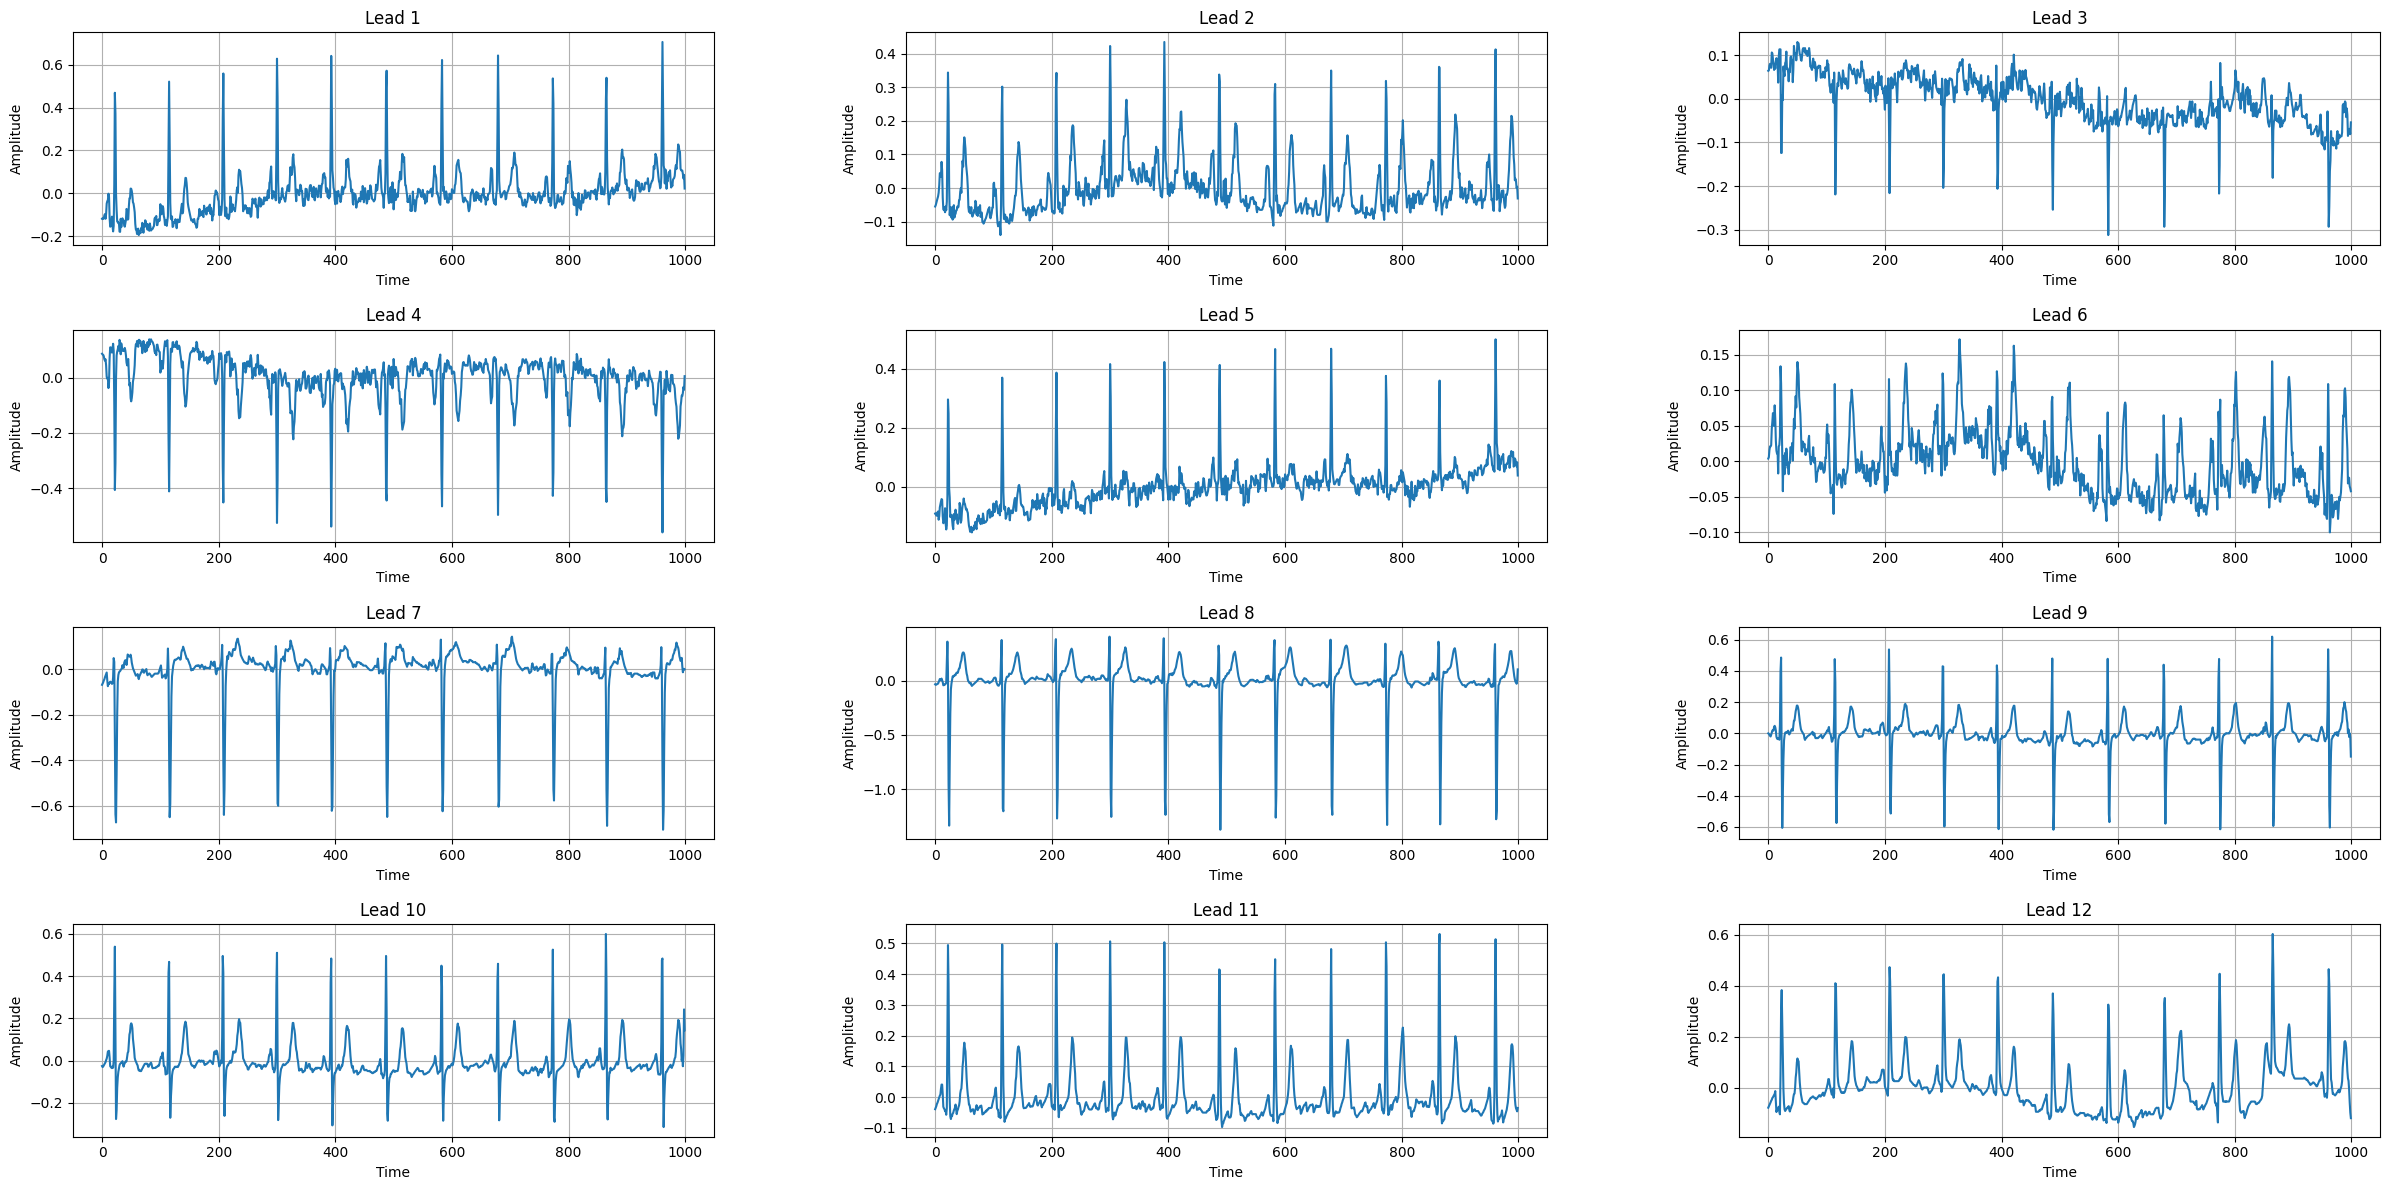

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_train[100][1].shape)
plot_ecg_12_leads(X_train[0, :] )